In [ ]:
# GEN install/load libraries for a generative model approach

# !pip -q install transformers datasets sentencepiece accelerate evaluate scikit-learn pandas

import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Libraries loaded for GEN approach.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00
Libraries loaded for GEN approach.


In [ ]:
# load dataset and prepare prompt-target pairs

import pandas as pd

train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

def safe_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def build_gen_input(row):
    src = safe_text(row["text_src"])
    tgt = safe_text(row["text_tgt"])

    prompt = "Classify the edit intent into one of these labels: Fact/Evidence, Grammar, Clarity, Claim, Other.\n"

    if src and tgt:
        prompt += f"Source text: {src}\nEdited text: {tgt}\nAnswer:"
    elif src:
        prompt += f"Source text: {src}\nEdited text: \nAnswer:"
    else:
        prompt += f"Source text: \nEdited text: {tgt}\nAnswer:"

    return prompt

train_df["input_text"] = train_df.apply(build_gen_input, axis=1)
val_df["input_text"] = val_df.apply(build_gen_input, axis=1)
test_df["input_text"] = test_df.apply(build_gen_input, axis=1)

train_df["target_text"] = train_df["label"].astype(str)
val_df["target_text"] = val_df["label"].astype(str)
test_df["target_text"] = test_df["label"].astype(str)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nSample GEN input:\n")
print(train_df["input_text"].iloc[0])

print("\nSample GEN target:")
print(train_df["target_text"].iloc[0])

Train shape: (7478, 10)
Validation shape: (1776, 10)
Test shape: (2312, 10)

Sample GEN input:

Classify the edit intent into one of these labels: Fact/Evidence, Grammar, Clarity, Claim, Other.
Source text: For MBTI, users were able to provide multiple texts, we report unique users in parentheses.
Edited text: 
Answer:

Sample GEN target:
Fact/Evidence


In [ ]:
# load tokenizer and generative model

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

gen_model_name = "google/flan-t5-small"

gen_tokenizer = AutoTokenizer.from_pretrained(gen_model_name)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(gen_model_name)

print("GEN model loaded successfully:", gen_model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

GEN model loaded successfully: google/flan-t5-small


In [ ]:
# convert to datasets and tokenize for seq2seq training

from datasets import Dataset

train_gen = Dataset.from_pandas(train_df[["input_text", "target_text"]])
val_gen = Dataset.from_pandas(val_df[["input_text", "target_text"]])
test_gen = Dataset.from_pandas(test_df[["input_text", "target_text"]])

max_input_length = 128
max_target_length = 16

def tokenize_gen(example):
    model_inputs = gen_tokenizer(
        example["input_text"],
        max_length=max_input_length,
        truncation=True,
        padding="max_length"
    )

    labels = gen_tokenizer(
        text_target=example["target_text"],
        max_length=max_target_length,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_gen_tokenized = train_gen.map(tokenize_gen, batched=True)
val_gen_tokenized = val_gen.map(tokenize_gen, batched=True)
test_gen_tokenized = test_gen.map(tokenize_gen, batched=True)

print("GEN tokenization completed.")
print("\nSample tokenized item:")
print({
    "input_ids": train_gen_tokenized[0]["input_ids"][:20],
    "labels": train_gen_tokenized[0]["labels"][:10]
})

Map:   0%|          | 0/7478 [00:00<?, ? examples/s]

Map:   0%|          | 0/1776 [00:00<?, ? examples/s]

Map:   0%|          | 0/2312 [00:00<?, ? examples/s]

GEN tokenization completed.

Sample tokenized item:
{'input_ids': [4501, 4921, 8, 4777, 9508, 139, 80, 13, 175, 11241, 10, 11543, 87, 427, 6961, 1433, 6, 30751, 6, 9908], 'labels': [11543, 87, 427, 6961, 1433, 1, 0, 0, 0, 0]}


In [ ]:
# set format and define evaluation metric for generated labels

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

columns_to_keep = ["input_ids", "attention_mask", "labels"]

train_gen_tokenized.set_format(type="torch", columns=columns_to_keep)
val_gen_tokenized.set_format(type="torch", columns=columns_to_keep)
test_gen_tokenized.set_format(type="torch", columns=columns_to_keep)

label_list = ["Fact/Evidence", "Grammar", "Clarity", "Claim", "Other"]

def clean_generated_text(text):
    text = text.strip()
    for label in label_list:
        if text.lower() == label.lower():
            return label
    return "Other"

def compute_gen_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = gen_tokenizer.batch_decode(predictions, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, gen_tokenizer.pad_token_id)
    decoded_labels = gen_tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [clean_generated_text(x) for x in decoded_preds]
    decoded_labels = [clean_generated_text(x) for x in decoded_labels]

    y_true = decoded_labels
    y_pred = decoded_preds

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("GEN dataset format ready.")
print("Labels used:", label_list)

GEN dataset format ready.
Labels used: ['Fact/Evidence', 'Grammar', 'Clarity', 'Claim', 'Other']


In [ ]:
# train the GEN model

import torch
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

gen_data_collator = DataCollatorForSeq2Seq(
    tokenizer=gen_tokenizer,
    model=gen_model
)

gen_training_args = Seq2SeqTrainingArguments(
    output_dir="./gen_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=16,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

gen_trainer = Seq2SeqTrainer(
    model=gen_model,
    args=gen_training_args,
    train_dataset=train_gen_tokenized,
    eval_dataset=val_gen_tokenized,
    data_collator=gen_data_collator,
    compute_metrics=compute_gen_metrics
)

gen_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/transformers/data/data_collator.py:600: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,7.107250,5.349158,0.436937,0.190914,0.436937,0.265723
2,5.527469,4.868932,0.436937,0.190914,0.436937,0.265723
3,5.206603,4.737477,0.436937,0.190914,0.436937,0.265723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=2805, training_loss=5.9471073905414436, metrics={'train_runtime': 13261.3437, 'train_samples_per_second': 1.692, 'train_steps_per_second': 0.212, 'total_flos': 1042566895632384.0, 'train_loss': 5.9471073905414436, 'epoch': 3.0})

In [ ]:
# evaluate GEN model on test set

gen_test_results = gen_trainer.evaluate(test_gen_tokenized)
print(gen_test_results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 5.354963302612305, 'eval_accuracy': 0.4515570934256055, 'eval_precision': 0.20390380862298105, 'eval_recall': 0.4515570934256055, 'eval_f1': 0.28094493774513235, 'eval_runtime': 671.3513, 'eval_samples_per_second': 3.444, 'eval_steps_per_second': 0.43, 'epoch': 3.0}


In [ ]:
# generate predictions on test set

gen_predictions_output = gen_trainer.predict(test_gen_tokenized)

print("Prediction step completed.")
print("Prediction array shape:", gen_predictions_output.predictions.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Prediction step completed.
Prediction array shape: (2312, 20)


In [ ]:
#  decode generated predictions and true labels

import numpy as np

gen_pred_ids = gen_predictions_output.predictions

if isinstance(gen_pred_ids, tuple):
    gen_pred_ids = gen_pred_ids[0]

gen_decoded_preds = gen_tokenizer.batch_decode(gen_pred_ids, skip_special_tokens=True)

gen_label_ids = gen_predictions_output.label_ids
gen_label_ids = np.where(gen_label_ids != -100, gen_label_ids, gen_tokenizer.pad_token_id)
gen_decoded_labels = gen_tokenizer.batch_decode(gen_label_ids, skip_special_tokens=True)

gen_decoded_preds = [clean_generated_text(x) for x in gen_decoded_preds]
gen_decoded_labels = [clean_generated_text(x) for x in gen_decoded_labels]

print("Sample decoded predictions:")
for i in range(5):
    print("Pred:", gen_decoded_preds[i], "| True:", gen_decoded_labels[i])

Sample decoded predictions:
Pred: Fact/Evidence | True: Fact/Evidence
Pred: Fact/Evidence | True: Fact/Evidence
Pred: Fact/Evidence | True: Claim
Pred: Fact/Evidence | True: Claim
Pred: Fact/Evidence | True: Claim


In [ ]:
#  classification report

from sklearn.metrics import classification_report

print(classification_report(gen_decoded_labels, gen_decoded_preds, labels=label_list, zero_division=0))

               precision    recall  f1-score   support

Fact/Evidence       0.45      1.00      0.62      1044
      Grammar       0.00      0.00      0.00       356
      Clarity       0.00      0.00      0.00       520
        Claim       0.00      0.00      0.00       325
        Other       0.00      0.00      0.00        67

     accuracy                           0.45      2312
    macro avg       0.09      0.20      0.12      2312
 weighted avg       0.20      0.45      0.28      2312



               Fact/Evidence  Grammar  Clarity  Claim  Other
Fact/Evidence           1044        0        0      0      0
Grammar                  356        0        0      0      0
Clarity                  520        0        0      0      0
Claim                    325        0        0      0      0
Other                     67        0        0      0      0


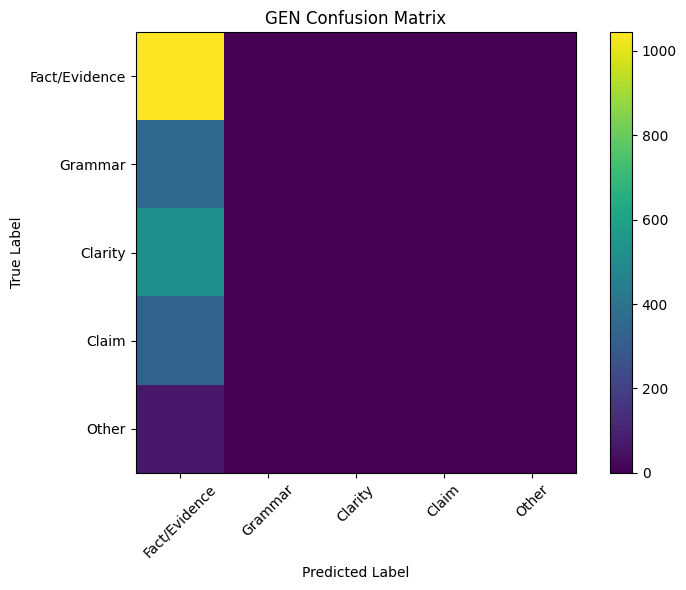

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

gen_cm = confusion_matrix(gen_decoded_labels, gen_decoded_preds, labels=label_list)

gen_cm_df = pd.DataFrame(gen_cm, index=label_list, columns=label_list)
print(gen_cm_df)

plt.figure(figsize=(8, 6))
plt.imshow(gen_cm, interpolation="nearest")
plt.title("GEN Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_list)), label_list, rotation=45)
plt.yticks(range(len(label_list)), label_list)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
#  save GEN model

from google.colab import drive
drive.mount('/content/drive')

gen_save_path = "/content/drive/MyDrive/gen_final_model"

gen_trainer.save_model(gen_save_path)
gen_tokenizer.save_pretrained(gen_save_path)

print("GEN model saved at:", gen_save_path)

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GEN model saved at: /content/drive/MyDrive/gen_final_model
